In [16]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from collections import Counter

In [ ]:
#Using polars libary, faster than pandas 
df_sanger = pl.read_csv("data/rnaseq_merged_rsem_tpm_20260323.csv")
print(df_sanger.shape)

(41148, 1901)


In [18]:
header_row = pl.DataFrame({col: [col] for col in df_sanger.columns})
df_sanger = pl.concat([header_row, df_sanger])
df_sanger

model_id,,_duplicated_0,SIDM00001,SIDM00002,SIDM00003,SIDM00005,SIDM00006,SIDM00007,SIDM00008,SIDM00009,SIDM00011,SIDM00014,SIDM00015,SIDM00016,SIDM00017,SIDM00018,SIDM00023,SIDM00025,SIDM00026,SIDM00027,SIDM00028,SIDM00029,SIDM00032,SIDM00035,SIDM00036,SIDM00037,SIDM00040,SIDM00041,SIDM00042,SIDM00043,SIDM00044,SIDM00045,SIDM00046,SIDM00047,SIDM00048,SIDM00049,…,SIDM02235,SIDM02236,SIDM02237,SIDM02238,SIDM02239,SIDM02240,SIDM02241,SIDM02242,SIDM02243,SIDM02244,SIDM02245,SIDM02246,SIDM02247,SIDM02248,SIDM02249,SIDM02250,SIDM02251,SIDM02252,SIDM02253,SIDM02254,SIDM02255,SIDM02256,SIDM02257,SIDM02258,SIDM02259,SIDM02260,SIDM02261,SIDM02262,SIDM02263,SIDM02264,SIDM02265,SIDM02266,SIDM02267,SIDM02268,SIDM02269,SIDM02270,SIDM02271
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""model_id""","""""","""_duplicated_0""","""SIDM00001""","""SIDM00002""","""SIDM00003""","""SIDM00005""","""SIDM00006""","""SIDM00007""","""SIDM00008""","""SIDM00009""","""SIDM00011""","""SIDM00014""","""SIDM00015""","""SIDM00016""","""SIDM00017""","""SIDM00018""","""SIDM00023""","""SIDM00025""","""SIDM00026""","""SIDM00027""","""SIDM00028""","""SIDM00029""","""SIDM00032""","""SIDM00035""","""SIDM00036""","""SIDM00037""","""SIDM00040""","""SIDM00041""","""SIDM00042""","""SIDM00043""","""SIDM00044""","""SIDM00045""","""SIDM00046""","""SIDM00047""","""SIDM00048""","""SIDM00049""",…,"""SIDM02235""","""SIDM02236""","""SIDM02237""","""SIDM02238""","""SIDM02239""","""SIDM02240""","""SIDM02241""","""SIDM02242""","""SIDM02243""","""SIDM02244""","""SIDM02245""","""SIDM02246""","""SIDM02247""","""SIDM02248""","""SIDM02249""","""SIDM02250""","""SIDM02251""","""SIDM02252""","""SIDM02253""","""SIDM02254""","""SIDM02255""","""SIDM02256""","""SIDM02257""","""SIDM02258""","""SIDM02259""","""SIDM02260""","""SIDM02261""","""SIDM02262""","""SIDM02263""","""SIDM02264""","""SIDM02265""","""SIDM02266""","""SIDM02267""","""SIDM02268""","""SIDM02269""","""SIDM02270""","""SIDM02271"""
"""model_name""",null,null,"""MEC-1""","""NBsusSR""","""M14""","""MDA-MB-134-VI""","""MCC26""","""MCC13""","""MCAS""","""MC-1010""","""Malme-3M""","""LIM1215""","""KYSE-30""","""KP-N-S19s""","""NCI-H2286""","""K052""","""TE-12""","""UDSCC2""","""TASK1""","""SK-NEP-1""","""SCLC-22H""","""SCLC-21H""","""SCaBER""","""S-117""","""OUMS-23""","""Ishikawa(Heraklio)02ER-""","""TMK-1""","""STS-0421""","""PL4""","""PCI-4B""","""PCI-30""","""HSC-39""","""H3255""","""EMC-BAC-2""","""EMC-BAC-1""","""DiFi""",…,"""WTSI-COLIVM_054""","""WTSI-COLIVM_052""","""WTSI-COLIVM_048""","""WTSI-COLIVM_046""","""WTSI-COLIVM_045""","""WTSI-COLIVM_041""","""WTSI-COLIVM_040""","""WTSI-COLIVM_060""","""WTSI-GAST_199""","""WTSI-COLIVM_087""","""WTSI-COLIVM_090""","""WTSI-GAST_186""","""WTSI-GAST_183""","""WTSI-COLO_502""","""WTSI-COLO_494""","""WTSI-COLO_493""","""WTSI-COLO_491""","""WTSI-COLO_478""","""WTSI-COLO_475""","""WTSI-COLO_471""","""WTSI-COLO_466""","""WTSI-COLIVM_089""","""WTSI-COLO_458""","""WTSI-COLO_449""","""WTSI-COLO_446""","""WTSI-COLO_439""","""WTSI-COLO_435""","""WTSI-COLO_427""","""WTSI-COLO_425""","""WTSI-COLO_061""","""WTSI-COLIVM_100""","""WTSI-COLIVM_093""","""WTSI-COLIVM_092""","""WTSI-COLO_452""","""WTSI-PANC_131""","""WTSI-COLIVM_068""","""WTSI-GAST_200"""
"""data_source""",null,null,"""Broad""","""Sanger""","""Sanger""","""Broad""","""Sanger""","""Sanger""","""Broad""","""Sanger""","""Broad""","""Sanger""","""Broad""","""Broad""","""Broad""","""Sanger""","""Sanger""","""Sanger""","""Sanger""","""Sanger""","""Broad""","""Broad""","""Broad""","""Broad""","""Broad""","""Broad""","""Sanger""","""Sanger""","""Sanger""","""Sanger""","""Sanger""","""Sanger""","""Broad""","""Sanger""","""Sanger""","""Sanger""",…,"""Sanger""","""Sanger""","""Sanger""","""Sanger""","""S

In [19]:
#transpo
df_sanger = df_sanger.transpose()
df_sanger

column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,…,column_41112,column_41113,column_41114,column_41115,column_41116,column_41117,column_41118,column_41119,column_41120,column_41121,column_41122,column_41123,column_41124,column_41125,column_41126,column_41127,column_41128,column_41129,column_41130,column_41131,column_41132,column_41133,column_41134,column_41135,column_41136,column_41137,column_41138,column_41139,column_41140,column_41141,column_41142,column_41143,column_41144,column_41145,column_41146,column_41147,column_41148
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""model_id""","""model_name""","""data_source""","""gene_symbol""","""A1BG""","""A1BG-AS1""","""A1CF""","""A2M""","""A2M-AS1""","""A2ML1""","""A2ML1-AS1""","""A2ML1-AS2""","""A2MP1""","""A3GALT2""","""A4GALT""","""A4GNT""","""AAAS""","""AACS""","""AACSP1""","""AADAC""","""AADACL2""","""AADACL2-AS1""","""AADACL3""","""AADACL4""","""AADACP1""","""AADAT""","""AAGAB""","""AAK1""","""AAMDC""","""AAMP""","""AANAT""","""AAR2""","""AARD""","""AARS1""","""AARS1P1""","""AARS2""","""AARSD1""",…,"""ZSCAN30""","""ZSCAN31""","""ZSCAN32""","""ZSCAN4""","""ZSCAN5A""","""ZSCAN5A-AS1""","""ZSCAN5B""","""ZSCAN5C""","""ZSCAN5DP""","""ZSCAN9""","""ZSWIM1""","""ZSWIM2""","""ZSWIM3""","""ZSWIM4""","""ZSWIM5""","""ZSWIM5P1""","""ZSWIM5P2""","""ZSWIM5P3""","""ZSWIM6""","""ZSWIM7""","""ZSWIM8""","""ZSWIM8-AS1""","""ZSWIM9""","""ZUP1""","""ZW10""","""ZWILCH""","""ZWINT""","""ZXDA""","""ZXDB""","""ZXDC""","""ZYG11A""","""ZYG11AP1""","""ZYG11B""","""ZYX""","""ZYXP1""","""ZZEF1""","""ZZZ3"""
"""""",null,null,"""ensembl_gene_id""","""ENSG00000121410""","""ENSG00000268895""","""ENSG00000148584""","""ENSG00000175899""","""ENSG00000245105""","""ENSG00000166535""","""ENSG00000256661""","""ENSG00000256904""","""ENSG00000256069""","""ENSG00000184389""","""ENSG00000128274""","""ENSG00000118017""","""ENSG00000094914""","""ENSG00000081760""","""ENSG00000250420""","""ENSG00000114771""","""ENSG00000197953""","""ENSG00000242908""","""ENSG00000188984""","""ENSG00000204518""","""ENSG00000240602""","""ENSG00000109576""","""ENSG00000103591""","""ENSG00000115977""","""ENSG00000087884""","""ENSG00000127837""","""ENSG00000129673""","""ENSG00000131043""","""ENSG00000205002""","""ENSG00000090861""","""ENSG00000249038""","""ENSG00000124608""","""ENSG00000266967""",…,"""ENSG00000186814""","""ENSG00000235109""","""ENSG00000140987""","""ENSG00000180532""","""ENSG00000131848""","""ENSG00000267549""","""ENSG00000197213""","""ENSG00000204532""","""ENSG00000267908""","""ENSG00000137185""","""ENSG00000168612""","""ENSG00000163012""","""ENSG00000132801""","""ENSG00000132003""","""ENSG00000162415""","""ENSG00000235430""","""ENSG00000231258""","""ENSG00000248958""","""ENSG00000130449""","""ENSG00000214941""","""ENSG00000214655""","""ENSG00000272589""","""ENSG00000185453""","""ENSG00000153975""","""ENSG00000086827""","""ENSG00000174442""","""ENSG00000122952""","""ENSG00000198205""","""ENSG00000198455""","""ENSG00000070476""","""ENSG00000203995""","""ENSG00000232242""","""ENSG00000162378""","""ENSG00000159840""","""ENSG00000274572""","""ENSG00000074755""","""ENSG00000036549"""
"""_duplicated_0""",null,null,"""gene_id""","""SIDG00001""","""SIDG00002""","""SIDG00003""","""SIDG00004""","""SIDG00005""","""SIDG00006""","""SIDG00007""","""SIDG00008""","""SIDG00009""","""SIDG00010""","""SIDG00011""","""SIDG00012""","""SIDG00017""","""SIDG00019""","""SIDG00020""","""SIDG00021""",

In [20]:
# récupérer les colonnes
new_columns = df_sanger.row(0)
df_sanger.columns = new_columns
df_sanger = df_sanger.slice(1)

In [21]:
df_sanger = df_sanger.slice(2)
df_sanger = df_sanger.drop('gene_symbol')
df_sanger

model_id,model_name,data_source,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,AADAC,AADACL2,AADACL2-AS1,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMDC,AAMP,AANAT,AAR2,AARD,AARS1,AARS1P1,AARS2,AARSD1,AARSD1P1,…,ZSCAN30,ZSCAN31,ZSCAN32,ZSCAN4,ZSCAN5A,ZSCAN5A-AS1,ZSCAN5B,ZSCAN5C,ZSCAN5DP,ZSCAN9,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM5P1,ZSWIM5P2,ZSWIM5P3,ZSWIM6,ZSWIM7,ZSWIM8,ZSWIM8-AS1,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""SIDM00001""","""MEC-1""","""Broad""","""3.853""","""1.8156""","""0""","""0.2388""","""0""","""0""","""0""","""0""","""0""","""0""","""0.3103""","""0""","""4.6017""","""4.5379""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0.0426""","""4.9198""","""2.3896""","""3.8758""","""5.9248""","""0.6415""","""4.2319""","""0.7824""","""8.2269""","""0""","""3.5957""","""5.9619""","""0.0976""",…,"""3.7214""","""1.7613""","""3.4396""","""0""","""2.2141""","""0.1506""","""0.0144""","""0""","""0""","""3.4647""","""2.6323""","""0""","""1.7949""","""2.4621""","""0.1243""","""0""","""0""","""0""","""1.7225""","""2.5969""","""5.3284""","""1.7312""","""2.774""","""2.9279""","""3.7495""","""4.1922""","""6.9332""","""0.7655""","""1.9561""","""2.8992""","""0.8953""","""0""","""1.926""","""4.1562""",null,"""3.0959""","""3.6792"""
"""SIDM00002""","""NBsusSR""","""Sanger""","""4.5059""","""2.3868""","""0.0286""","""0.5753""","""0.3448""","""0.4751""","""0""","""0""","""0.0144""","""0.189""","""3.7082""","""0.0566""","""6.5517""","""4.1938""","""0.1635""","""0.0426""","""0.0144""","""0""","""0""","""2.9928""","""0.2869""","""2.4673""","""4.8074""","""3.4087""","""4.9699""","""6.4075""","""1.5607""","""5.4761""","""0.1635""","""6.7067""","""0""","""3.5323""","""5.6441""","""1.111""",…,"""3.6668""","""1.9486""","""3.9193""","""0""","""3.0807""","""0.2265""","""0.0426""","""0.0144""","""0.0426""","""2.6392""","""3.6017""","""0.0704""","""2.2296""","""3.7312""","""2.2449""","""0""","""0""","""0""","""4.8934""","""4.1293""","""5.1767""","""0.7137""","""2.842""","""4.1969""","""5.3122""","""4.5521""","""6.1613""","""1.7137""","""2.6803""","""5.6156""","""0.848""","""0""","""3.7388""","""5.2687""","""0""","""4.3519""","""5.4182"""
"""SIDM00003""","""M14""","""Sanger""","""3.9736""","""3.1408""","""0.0144""","""4.1326""","""0.4114""","""0""","""0""","""0""","""0""","""0.0841""","""0.0144""","""0.251""","""6.128""","""4.8186""","""0.7398""","""0""","""0""","""0""","""0""","""0""","""0.0144""","""3.4033""","""5.9768""","""4.4861""","""4.1285""","""6.6307""","""0.4222""","""5.057""","""0.1763""","""5.302""","""0""","""3.851""","""4.963""","""0.0704""",…,"""2.5729""","""1.2449""","""3.009""","""0""","""2.8758""","""0.111""","""0.0426""","""0.0286""","""0.0144""","""3.0531""","""3.2854""","""0""","""1.844""","""1.6041""","""0.0566""","""0""","""0""","""0""","""2.5534""","""5.0496""","""4.5993""","""0.7049""","""2.3103""","""2.6439""","""5.1759""","""5.9001""","""7.6785""","""1.0909""","""2.101""","""4.0488""","""2.6369""","""0.0976""","""3.7148""","""6.959""","""0""","""4.3561""","""5.5622"""
"""SIDM00005""","""MDA-MB-134-VI""","""Broad""","""5.7038""","""3.3334""","""0.0566""","""0.5261""","""1.4489""","""0.4114""","""0""","""0""","""0.0426""","""0""","""1.6182""","""0.2016""","""6.1837""","""5.7436""","""0.1635""","""0""","""0""","""0.1375""","""0""","""0""","""0""","""3.7856""","""5.7287""","""2.0738""","""9.2241""","""6.4476""","""0.1375""","""4.9551""","""0.7049""","""5.1457""","""0""","""2.9709""","""5.7244""","""1.189""",…,"""4.4841""","""3.1194""","""3.6724""","""0""","""2.7027""","""1.111""","""0.0976""","""0""","""0.0841""","""

In [22]:
df_sanger = df_sanger.with_columns(
    pl.exclude(["model_id", "model_name", "data_source"]).cast(pl.Float64, strict=False)
)
df_sanger = df_sanger.rename({"model_id" : "SANGER_MODEL_ID"})
df_sanger

SANGER_MODEL_ID,model_name,data_source,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,AADAC,AADACL2,AADACL2-AS1,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMDC,AAMP,AANAT,AAR2,AARD,AARS1,AARS1P1,AARS2,AARSD1,AARSD1P1,…,ZSCAN30,ZSCAN31,ZSCAN32,ZSCAN4,ZSCAN5A,ZSCAN5A-AS1,ZSCAN5B,ZSCAN5C,ZSCAN5DP,ZSCAN9,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM5P1,ZSWIM5P2,ZSWIM5P3,ZSWIM6,ZSWIM7,ZSWIM8,ZSWIM8-AS1,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SIDM00001""","""MEC-1""","""Broad""",3.853,1.8156,0.0,0.2388,0.0,0.0,0.0,0.0,0.0,0.0,0.3103,0.0,4.6017,4.5379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0426,4.9198,2.3896,3.8758,5.9248,0.6415,4.2319,0.7824,8.2269,0.0,3.5957,5.9619,0.0976,…,3.7214,1.7613,3.4396,0.0,2.2141,0.1506,0.0144,0.0,0.0,3.4647,2.6323,0.0,1.7949,2.4621,0.1243,0.0,0.0,0.0,1.7225,2.5969,5.3284,1.7312,2.774,2.9279,3.7495,4.1922,6.9332,0.7655,1.9561,2.8992,0.8953,0.0,1.926,4.1562,null,3.0959,3.6792
"""SIDM00002""","""NBsusSR""","""Sanger""",4.5059,2.3868,0.0286,0.5753,0.3448,0.4751,0.0,0.0,0.0144,0.189,3.7082,0.0566,6.5517,4.1938,0.1635,0.0426,0.0144,0.0,0.0,2.9928,0.2869,2.4673,4.8074,3.4087,4.9699,6.4075,1.5607,5.4761,0.1635,6.7067,0.0,3.5323,5.6441,1.111,…,3.6668,1.9486,3.9193,0.0,3.0807,0.2265,0.0426,0.0144,0.0426,2.6392,3.6017,0.0704,2.2296,3.7312,2.2449,0.0,0.0,0.0,4.8934,4.1293,5.1767,0.7137,2.842,4.1969,5.3122,4.5521,6.1613,1.7137,2.6803,5.6156,0.848,0.0,3.7388,5.2687,0.0,4.3519,5.4182
"""SIDM00003""","""M14""","""Sanger""",3.9736,3.1408,0.0144,4.1326,0.4114,0.0,0.0,0.0,0.0,0.0841,0.0144,0.251,6.128,4.8186,0.7398,0.0,0.0,0.0,0.0,0.0,0.0144,3.4033,5.9768,4.4861,4.1285,6.6307,0.4222,5.057,0.1763,5.302,0.0,3.851,4.963,0.0704,…,2.5729,1.2449,3.009,0.0,2.8758,0.111,0.0426,0.0286,0.0144,3.0531,3.2854,0.0,1.844,1.6041,0.0566,0.0,0.0,0.0,2.5534,5.0496,4.5993,0.7049,2.3103,2.6439,5.1759,5.9001,7.6785,1.0909,2.101,4.0488,2.6369,0.0976,3.7148,6.959,0.0,4.3561,5.5622
"""SIDM00005""","""MDA-MB-134-VI""","""Broad""",5.7038,3.3334,0.0566,0.5261,1.4489,0.4114,0.0,0.0,0.0426,0.0,1.6182,0.2016,6.1837,5.7436,0.1635,0.0,0.0,0.1375,0.0,0.0,0.0,3.7856,5.7287,2.0738,9.2241,6.4476,0.1375,4.9551,0.7049,5.1457,0.0,2.9709,5.7244,1.189,…,4.4841,3.1194,3.6724,0.0,2.7027,1.111,0.0976,0.0,0.0841,4.4195,2.7355,0.0,1.6871,1.5705,1.3561,0.0144,0.0,0.0144,2.8197,4.0426,7.3509,2.3306,1.6871,3.9165,2.6253,4.2765,7.03,1.7093,2.257,4.3111,1.0909,0.0,2.4463,4.0009,null,3.3813,4.2434
"""SIDM00006""","""MCC26""","""Sanger""",3.9069,2.5801,0.0426,5.6562,0.5656,0.1506,0.0,0.0,0.0286,0.1635,3.4931,0.1506,5.0409,3.9298,0.251,0.0,0.0,0.0,0.0,0.1375,0.0704,3.157,5.6764,5.0561,4.4938,6.5721,0.3785,5.3067,2.0531,7.1754,0.0,3.4581,5.067,0.4957,…,3.5173,4.2411,3.6848,0.2016,3.0409,0.111,0.0286,0.0,0.0286,4.0233,3.4436,0.3334,1.9523,2.8298,2.4356,0.0,0.0,0.0,3.6747,4.2957,4.9155,0.8156,2.4276,3.7203,4.8202,5.0862,6.4819,1.4005,2.3533,3.9551,2.98,0.0,3.6334,8.5417,0.0,3.5211,5.1839
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SIDM02267""","""WTSI-COLIVM_092""","""Sanger""",3.5583,0.4957,1.9336,0.0,0.0566,0.0,0.0,0.0,0.0,0.0,0.669,0.0,3.319,3.1985,0.0,0.1243,0.0144,0.0,0.0,0.0,1.4594,1.5361,2.9392,2.2898,3.2795,4.9141,0.0,2.585,0.0,4.3723,0.0,1.5898,3.3205,0.3103,…,1.3785,1.7049,1.926,0.0,2.0179,0.0144,0.0,0.0,0.0566,2.359,2.6112,0.0,1.111,0.9928,0.4647,0.0,0.0,0.0,1.275,3.0391,4.1391,0.3448,1.4647,3.7949,1.7004,1.2388,3.319,0.3448,0.696,2.8237,0.0286,0.0,1.0286,4.1587,0.0,1.4542,2.3045
"""SIDM02268""","""WTSI-COLO_452""","""Sanger""",2.9635,0.3334,2.0144,0.263,0.275,0.0566,0.0,0.0,0.0,0.

In [ ]:
#df_sanger.write_csv("data/Dataset_sanger.csv")

In [24]:
df_sanger = df_sanger[:, :5]
df_sanger

SANGER_MODEL_ID,model_name,data_source,A1BG,A1BG-AS1
str,str,str,f64,f64
"""SIDM00001""","""MEC-1""","""Broad""",3.853,1.8156
"""SIDM00002""","""NBsusSR""","""Sanger""",4.5059,2.3868
"""SIDM00003""","""M14""","""Sanger""",3.9736,3.1408
"""SIDM00005""","""MDA-MB-134-VI""","""Broad""",5.7038,3.3334
"""SIDM00006""","""MCC26""","""Sanger""",3.9069,2.5801
…,…,…,…,…
"""SIDM02267""","""WTSI-COLIVM_092""","""Sanger""",3.5583,0.4957
"""SIDM02268""","""WTSI-COLO_452""","""Sanger""",2.9635,0.3334
"""SIDM02269""","""WTSI-PANC_131""","""Sanger""",0.0,0.8953


In [25]:
df_model = pl.read_csv("data/Model.csv")
df_model = df_model.rename({"COSMICID": "COSMIC_ID"})
df_model = df_model.cast({"COSMIC_ID": pl.Int64})
df_model.head()

ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,RRID,Age,AgeCategory,Sex,PatientRace,PrimaryOrMetastasis,SampleCollectionSite,SourceType,SourceDetail,CatalogNumber,ModelType,TissueOrigin,ModelDerivationMaterial,ModelTreatment,PatientTreatmentStatus,PatientTreatmentType,PatientTreatmentDetails,Stage,StagingSystem,PatientTumorGrade,PatientTreatmentResponse,GrowthPattern,OnboardedMedia,FormulationID,SerumFreeMedia,PlateCoating,EngineeredModel,EngineeredModelDetails,CulturedResistanceDrug,PublicComments,CCLEName,HCMIID,PediatricModelType,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SANGER_MODEL_ID,COSMIC_ID,ModelIDAlias
str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,str,str,str,str,str,str,str,bool,str,str,f64,str,i64,str
"""ACH-000001""","""PT-gj46wT""","""NIH:OVCAR-3""","""NIHOVCAR3""","""HGSOC""","""Ovary/Fallopian Tube""","""Ovarian Epithelial Tumor""","""High-Grade Serous Ovarian Canc…","""HGSOC""",null,"""CVCL_0465""",60.0,"""Adult""","""Female""","""caucasian""","""Metastatic""","""ascites""","""ATCC""",null,"""HTB-71""","""Cell Line""",null,null,null,null,null,null,null,null,null,null,"""Adherent""","""MF-001-041""","""RPMI + 20% FBS + 0.01 mg/ml in…",false,"""None""",null,null,null,null,"""NIHOVCAR3_OVARY""",null,false,"""Approved for public sharing - …",null,2201.0,"""SIDM00105""",905933,null
"""ACH-000002""","""PT-5qa3uk""","""HL-60""","""HL60""","""AMLMRC""","""Myeloid""","""Acute Myeloid Leukemia""","""AML with Myelodysplasia-Relate…","""AMLMRC""","""TP53(del), CDKN2A and NRAS mut…","""CVCL_0002""",36.0,"""Adult""","""Female""","""caucasian""","""Primary""","""haematopoietic_and_lymphoid_ti…","""ATCC""",null,"""CCL-240""","""Cell Line""",null,null,null,null,null,null,null,null,null,null,"""Suspension""","""MF-005-001""","""IMDM + 10% FBS""",false,"""None""",null,null,null,null,"""HL60_HAEMATOPOIETIC_AND_LYMPHO…",null,true,"""Approved for public sharing - …","""NRAS, BCOR and CDKN2A""",55.0,"""SIDM00829""",905938,null
"""ACH-000003""","""PT-puKIyc""","""CACO2""","""CACO2""","""COAD""","""Bowel""","""Colorectal Adenocarcinoma""","""Colon Adenocarcinoma""","""COAD""",null,"""CVCL_0025""",72.0,"""Adult""","""Male""","""caucasian""","""Primary""","""Colon""","""ATCC""",null,"""HTB-37""","""Cell Line""",null,null,null,"""Unknown""",null,null,null,null,null,null,"""Adherent""","""MF-015-009""","""EMEM + 20% FBS""",false,"""None""",null,null,null,null,"""CACO2_LARGE_INTESTINE""",null,false,"""Approved for public sharing - …",null,null,"""SIDM00891""",null,null
"""ACH-000004""","""PT-q4K2cp""","""HEL""","""HEL""","""AMLNOS""","""Myeloid""","""Acute Myeloid Leukemia""","""AML, NOS""","""AMLNOS""","""JAK2 and TP53 mutations""","""CVCL_0001""",30.0,"""Adult""","""Male""","""caucasian""","""Primary""","""haematopoietic_and_lymphoid_ti…","""DSMZ""",null,"""ACC 11""","""Cell Line""",null,null,null,"""Post-treatment""",null,null,null,null,null,null,"""Suspension""","""MF-001-001""","""RPMI + 10% FBS""",false,"""None""",null,null,null,null,"""HEL_HAEMATOPOIETIC_AND_LYMPHOI…",null,true,"""Approved for public sharing - …","""JAK2 and TP53""",783.0,"""SIDM00594""",907053,null
"""ACH-000005""","""PT-q4K2cp""","""HEL 92.1.7""","""HEL9217""","""AML""","""Myeloid""","""Acute Myeloid Leukemia""","""Acute Myeloid Leukemia""","""AML""","""JAK2 and TP53 mutations""","""CVCL_2481""",30.0,"""Adult""","""Male""","""caucasian""",null,"""bone_marrow""","""ATCC""",null,"""HEL9217""","""Cell Line""",null,null,null,null,null,null,null,null,null,null,"""Mixed""","""MF-001-001""","""RPMI + 10% FBS""",false,"""None""",null,null,null,null,"""HEL9217_HAEMATOPOIETIC_AND_LYM…",null,true,"""Approved for public sharing - …",null,null,"""SIDM00593""",null,null


In [26]:
df_GDSC = pl.read_csv("data/Dataset_GDSC.csv")
df_GDSC.head()

DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
str,i64,i64,str,str,str,i64,str,str,str,f64,f64,f64,f64,f64,f64
"""GDSC1""",342,15600538,"""NCI-H82""","""SIDM01131""","""Small Cell Lung Carcinoma""",252,"""WZ3105""","""SRC, ROCK2, NTRK2, FLT3, IRAK1…","""Other""",0.005,10.24,-0.140674,0.820852,0.147322,-0.210958
"""GDSC2""",343,15951226,"""GB-1""","""SIDM00581""","""Glioblastoma""",1909,"""Venetoclax""","""BCL2""","""Apoptosis regulation""",0.001001,1.0,3.232005,0.963956,0.075839,0.657996
"""GDSC2""",343,15991332,"""MCF7""","""SIDM00148""","""Breast Carcinoma""",1131,"""PRIMA-1MET""","""TP53 activation""","""p53 pathway""",0.030016,30.0,6.875959,0.9743,0.072238,1.367293
"""GDSC1""",342,15582306,"""COLO-829""","""SIDM00909""","""Melanoma""",91,"""GSK319347A""","""IKK""","""Other, kinases""",0.019531,5.0,4.714267,0.97391,0.058732,1.383729
"""GDSC1""",342,15610477,"""SHP-77""","""SIDM01078""","""Small Cell Lung Carcinoma""",438,"""Panobinostat""","""HDAC""","""Chromatin histone acetylation""",0.004,1.024,-2.229306,0.587243,0.062027,0.590662


In [27]:
df_step1 = df_GDSC.join(
    df_model.select(['SANGER_MODEL_ID', 'ModelID', 'OncotreeLineage', 'OncotreePrimaryDisease']), 
    on='SANGER_MODEL_ID', 
    how='inner'
)
df_step1.head()

DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,ModelID,OncotreeLineage,OncotreePrimaryDisease
str,i64,i64,str,str,str,i64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str
"""GDSC1""",342,15600538,"""NCI-H82""","""SIDM01131""","""Small Cell Lung Carcinoma""",252,"""WZ3105""","""SRC, ROCK2, NTRK2, FLT3, IRAK1…","""Other""",0.005,10.24,-0.140674,0.820852,0.147322,-0.210958,"""ACH-000355""","""Lung""","""Lung Neuroendocrine Tumor"""
"""GDSC2""",343,15951226,"""GB-1""","""SIDM00581""","""Glioblastoma""",1909,"""Venetoclax""","""BCL2""","""Apoptosis regulation""",0.001001,1.0,3.232005,0.963956,0.075839,0.657996,"""ACH-000738""","""CNS/Brain""","""Diffuse Glioma"""
"""GDSC2""",343,15991332,"""MCF7""","""SIDM00148""","""Breast Carcinoma""",1131,"""PRIMA-1MET""","""TP53 activation""","""p53 pathway""",0.030016,30.0,6.875959,0.9743,0.072238,1.367293,"""ACH-000019""","""Breast""","""Invasive Breast Carcinoma"""
"""GDSC1""",342,15582306,"""COLO-829""","""SIDM00909""","""Melanoma""",91,"""GSK319347A""","""IKK""","""Other, kinases""",0.019531,5.0,4.714267,0.97391,0.058732,1.383729,"""ACH-000644""","""Skin""","""Melanoma"""
"""GDSC1""",342,15610477,"""SHP-77""","""SIDM01078""","""Small Cell Lung Carcinoma""",438,"""Panobinostat""","""HDAC""","""Chromatin histone acetylation""",0.004,1.024,-2.229306,0.587243,0.062027,0.590662,"""ACH-000790""","""Lung""","""Lung Neuroendocrine Tumor"""


In [28]:
df_step2 = df_step1.join(
        df_sanger,
        on='SANGER_MODEL_ID', 
        how='inner'
    )
df_step2

DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,ModelID,OncotreeLineage,OncotreePrimaryDisease,model_name,data_source,A1BG,A1BG-AS1
str,i64,i64,str,str,str,i64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64
"""GDSC1""",342,15600538,"""NCI-H82""","""SIDM01131""","""Small Cell Lung Carcinoma""",252,"""WZ3105""","""SRC, ROCK2, NTRK2, FLT3, IRAK1…","""Other""",0.005,10.24,-0.140674,0.820852,0.147322,-0.210958,"""ACH-000355""","""Lung""","""Lung Neuroendocrine Tumor""","""NCI-H82""","""Broad""",4.3176,2.5509
"""GDSC2""",343,15951226,"""GB-1""","""SIDM00581""","""Glioblastoma""",1909,"""Venetoclax""","""BCL2""","""Apoptosis regulation""",0.001001,1.0,3.232005,0.963956,0.075839,0.657996,"""ACH-000738""","""CNS/Brain""","""Diffuse Glioma""","""GB-1""","""Broad""",0.0,0.111
"""GDSC2""",343,15991332,"""MCF7""","""SIDM00148""","""Breast Carcinoma""",1131,"""PRIMA-1MET""","""TP53 activation""","""p53 pathway""",0.030016,30.0,6.875959,0.9743,0.072238,1.367293,"""ACH-000019""","""Breast""","""Invasive Breast Carcinoma""","""MCF7""","""Broad""",4.0858,2.8094
"""GDSC1""",342,15582306,"""COLO-829""","""SIDM00909""","""Melanoma""",91,"""GSK319347A""","""IKK""","""Other, kinases""",0.019531,5.0,4.714267,0.97391,0.058732,1.383729,"""ACH-000644""","""Skin""","""Melanoma""","""COLO-829""","""Broad""",4.3806,3.3992
"""GDSC1""",342,15610477,"""SHP-77""","""SIDM01078""","""Small Cell Lung Carcinoma""",438,"""Panobinostat""","""HDAC""","""Chromatin histone acetylation""",0.004,1.024,-2.229306,0.587243,0.062027,0.590662,"""ACH-000790""","""Lung""","""Lung Neuroendocrine Tumor""","""SHP-77""","""Broad""",3.9383,1.9819
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GDSC2""",343,16047396,"""ML-2""","""SIDM00441""","""Acute Myeloid Leukemia""",1720,"""AZD5991""","""MCL1""","""Apoptosis regulation""",0.010005,10.0,-3.245473,0.222401,0.097853,-2.499111,"""ACH-002273""","""Myeloid""","""Acute Myeloid Leukemia""","""ML-2""","""Sanger""",3.9411,2.905
"""GDSC2""",343,16166867,"""HCC-33""","""SIDM01071""","""Small Cell Lung Carcinoma""",1009,"""Tretinoin""","""Retinoic acid""","""Other""",0.010005,10.0,3.18403,0.938204,0.136701,-1.557273,"""ACH-000515""","""Lung""","""Lung Neuroendocrine Tumor""","""HCC-33""","""Broad""",4.4906,3.5008
"""GDSC2""",343,15971456,"""HCC2157""","""SIDM00774""","""Breast Carcinoma""",2000,"""N27922-53-1""",null,"""Unclassified""",0.010005,10.0,4.894122,0.989773,0.139894,-0.28403,"""ACH-000691""","""Breast""","""Invasive Breast Carcinoma""","""HCC2157""","""Broad""",1.2388,2.0215


In [29]:
df_step2["SANGER_MODEL_ID"].n_unique()

951

In [30]:
#BRAF_mut
df_BRAF_Mut = pl.read_csv("data/BRAF_Mut.csv")

df_braf_mut = (
    df_BRAF_Mut
    .filter(pl.col("gene") == "BRAF") # Keep BRAF
    .select([
        pl.col("depmap_id").alias("ModelID"), # key Id for join
        pl.col("protein_change") # Keep the protein change information
    ])
    .with_columns(pl.lit(1).alias("BRAF_Mut")) # On ajoute un "1" pour dire "Muté"
    .unique(subset=["ModelID"]) # Duplicates
)

In [31]:
df_BRAF_Mut["depmap_id"].n_unique()

213

In [32]:
cols_to_drop = ["NLME_RESULT_ID", "NLME_CURVE_ID"]

df_final = (
    df_step2
    .filter(pl.col('OncotreePrimaryDisease') == 'Melanoma')
    .drop(cols_to_drop)
)
print(df_final["SANGER_MODEL_ID"].n_unique())
df_final = (
    df_final
    .join(df_braf_mut, on="ModelID", how="left")
    .with_columns(pl.col("BRAF_Mut").fill_null(0))
)

#df_final = df_final.filter(pl.col('PUTATIVE_TARGET') == 'BRAF')
#print(df_final["SANGER_MODEL_ID"].n_unique())
df_final

52


DATASET,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,ModelID,OncotreeLineage,OncotreePrimaryDisease,model_name,data_source,A1BG,A1BG-AS1,protein_change,BRAF_Mut
str,str,str,str,i64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,str,i32
"""GDSC1""","""COLO-829""","""SIDM00909""","""Melanoma""",91,"""GSK319347A""","""IKK""","""Other, kinases""",0.019531,5.0,4.714267,0.97391,0.058732,1.383729,"""ACH-000644""","""Skin""","""Melanoma""","""COLO-829""","""Broad""",4.3806,3.3992,"""p.V600E""",1
"""GDSC1""","""LOXIMVI""","""SIDM00149""","""Melanoma""",1453,"""RAF_9304""","""ARAF, BRAF, CRAF""","""ERK MAPK signaling""",0.039063,10.0,-0.697419,0.463761,0.125901,-2.248342,"""ACH-000750""","""Skin""","""Melanoma""","""LOXIMVI""","""Broad""",0.0,0.0426,"""p.V600E""",1
"""GDSC1""","""SK-MEL-30""","""SIDM00392""","""Melanoma""",255,"""CP724714""","""ERBB2""","""EGFR signaling""",0.04,10.24,3.904651,0.959107,0.102642,-0.351846,"""ACH-000810""","""Skin""","""Melanoma""","""SK-MEL-30""","""Broad""",4.9117,3.278,"""p.D287H""",1
"""GDSC2""","""HT-144""","""SIDM00695""","""Melanoma""",1820,"""123829""",null,"""Unclassified""",0.003002,3.0,2.497361,0.947747,0.093525,-0.053623,"""ACH-000322""","""Skin""","""Melanoma""","""HT-144""","""Broad""",5.2102,3.7602,"""p.V600E""",1
"""GDSC1""","""SH-4""","""SIDM01079""","""Melanoma""",1419,"""FEN1_3940""","""FEN1""","""Genome integrity""",0.039063,10.0,0.73173,0.658568,0.147135,-1.538813,"""ACH-000441""","""Skin""","""Melanoma""","""SH-4""","""Broad""",4.9777,3.6112,"""p.V600E""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GDSC1""","""451Lu""","""SIDM01240""","""Melanoma""",317,"""WYE-125132""","""mTOR""","""PI3K/MTOR signaling""",0.04,10.24,-1.489837,0.339204,0.284107,-0.635157,"""ACH-001002""","""Skin""","""Melanoma""","""451Lu""","""Sanger""",5.0704,3.3406,"""p.V600E""",1
"""GDSC1""","""MEL-JUSO""","""SIDM00336""","""Melanoma""",363,"""PF-00299804""","""EGFR, ERBB2, ERBB4""","""RTK signaling""",0.078125,20.0,2.616065,0.832094,0.165071,0.61831,"""ACH-000881""","""Skin""","""Melanoma""","""MEL-JUSO""","""Broad""",4.7126,3.4236,null,0
"""GDSC1""","""K2""","""SIDM00126""","""Melanoma""",1262,"""UNC1215""","""L3MBTL3""","""Chromatin other""",0.003906,1.0,2.642057,0.966662,0.026771,0.42392,"""ACH-002147""","""Skin""","""Melanoma""","""K2""","""Sanger""",1.8156,2.2898,"""p.V600E""",1


In [33]:
# Fonction appliquée à chaque médicament
def classify_drug_responses(df_drug: pl.DataFrame) -> pl.DataFrame:
    
    df_valid = df_drug.filter(pl.col("LN_IC50").is_not_null() & pl.col("AUC").is_not_null())

    if len(df_valid) < 5:
        return df_drug.with_columns(pl.lit(None).cast(pl.Int32).alias("is_responder"))

    X = df_valid.select(["LN_IC50", "AUC"]).to_numpy()

    # Security
    try:
        gmm = GaussianMixture(n_components=2, n_init=15, random_state=42)
        labels = gmm.fit_predict(X) 
    except Exception:
        return df_drug.with_columns(pl.lit(None).cast(pl.Int32).alias("is_responder"))

    if len(np.unique(labels)) == 1:
        return df_drug.with_columns(pl.lit(None).cast(pl.Int32).alias("is_responder"))

    # 4. Identifier quel cluster est celui des "Répondeurs"
    # axis=0 permet de calculer la moyenne pour l'IC50 ET pour l'AUC.
    # centroid_0 donne donc un tableau : [moyenne_IC50, moyenne_AUC]
    centroid_0 = X[labels == 0].mean(axis=0)
    centroid_1 = X[labels == 1].mean(axis=0)

    # Le label du cluster qui a la plus petite moyenne d'IC50
    responder_label = 0 if centroid_0[0] < centroid_1[0] else 1

    global_mean_ic50 = X[:, 0].mean()
    global_mean_auc = X[:, 1].mean()
    
    # 5. Si le label est 1 (sensible) MAIS que l'IC50 OU l'AUC est supérieur à la moyenne globale, on force à 0
    final_labels = [
        1 if (label == responder_label and val_ic50 < global_mean_ic50 and val_auc < global_mean_auc) else 0 
        for label, (val_ic50, val_auc) in zip(labels, X)
    ]

    return df_valid.with_columns(pl.Series("is_responder", final_labels, dtype=pl.Int32))


print("Catégorisation par GMM (2D : IC50 + AUC) en cours...")

df_categorized = (
    df_final
    .group_by("DRUG_NAME")
    .map_groups(classify_drug_responses)
)

# Filtrer les potentiels médicaments qui n'avaient pas assez de données
df_categorized = df_categorized.drop_nulls(subset=["is_responder"])

print("Results :")
print(df_categorized.select(["ModelID", "DRUG_NAME", "LN_IC50", "AUC", "is_responder", "BRAF_Mut"]).head())

Catégorisation par GMM (2D : IC50 + AUC) en cours...
Results :
shape: (5, 6)
┌────────────┬─────────────┬──────────┬──────────┬──────────────┬──────────┐
│ ModelID    ┆ DRUG_NAME   ┆ LN_IC50  ┆ AUC      ┆ is_responder ┆ BRAF_Mut │
│ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---          ┆ ---      │
│ str        ┆ str         ┆ f64      ┆ f64      ┆ i32          ┆ i32      │
╞════════════╪═════════════╪══════════╪══════════╪══════════════╪══════════╡
│ ACH-002159 ┆ GSK2256098C ┆ 4.452257 ┆ 0.984185 ┆ 0            ┆ 1        │
│ ACH-000322 ┆ GSK2256098C ┆ 4.143729 ┆ 0.9842   ┆ 0            ┆ 1        │
│ ACH-001024 ┆ GSK2256098C ┆ 4.522616 ┆ 0.984914 ┆ 0            ┆ 0        │
│ ACH-000644 ┆ GSK2256098C ┆ 5.48092  ┆ 0.96797  ┆ 0            ┆ 1        │
│ ACH-000441 ┆ GSK2256098C ┆ 4.691847 ┆ 0.980703 ┆ 0            ┆ 1        │
└────────────┴─────────────┴──────────┴──────────┴──────────────┴──────────┘


In [34]:
df_categorized

DATASET,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,ModelID,OncotreeLineage,OncotreePrimaryDisease,model_name,data_source,A1BG,A1BG-AS1,protein_change,BRAF_Mut,is_responder
str,str,str,str,i64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,str,i32,i32
"""GDSC2""","""M14""","""SIDM00003""","""Melanoma""",1776,"""GSK2256098C""","""FAK1""","""Cytoskeleton""",0.003002,3.0,4.452257,0.984185,0.034648,0.178471,"""ACH-002159""","""Skin""","""Melanoma""","""M14""","""Sanger""",3.9736,3.1408,"""p.V600E""",1,0
"""GDSC2""","""HT-144""","""SIDM00695""","""Melanoma""",1776,"""GSK2256098C""","""FAK1""","""Cytoskeleton""",0.003002,3.0,4.143729,0.9842,0.060314,-0.157345,"""ACH-000322""","""Skin""","""Melanoma""","""HT-144""","""Broad""",5.2102,3.7602,"""p.V600E""",1,0
"""GDSC2""","""CHL-1""","""SIDM01228""","""Melanoma""",1776,"""GSK2256098C""","""FAK1""","""Cytoskeleton""",0.003002,3.0,4.522616,0.984914,0.057177,0.255053,"""ACH-001024""","""Skin""","""Melanoma""","""CHL-1""","""Sanger""",5.1412,2.8817,null,0,0
"""GDSC2""","""COLO-829""","""SIDM00909""","""Melanoma""",1776,"""GSK2256098C""","""FAK1""","""Cytoskeleton""",0.003002,3.0,5.48092,0.96797,0.046058,1.298111,"""ACH-000644""","""Skin""","""Melanoma""","""COLO-829""","""Broad""",4.3806,3.3992,"""p.V600E""",1,0
"""GDSC2""","""SH-4""","""SIDM01079""","""Melanoma""",1776,"""GSK2256098C""","""FAK1""","""Cytoskeleton""",0.003002,3.0,4.691847,0.980703,0.048573,0.43925,"""ACH-000441""","""Skin""","""Melanoma""","""SH-4""","""Broad""",4.9777,3.6112,"""p.V600E""",1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GDSC1""","""A2058""","""SIDM00797""","""Melanoma""",363,"""PF-00299804""","""EGFR, ERBB2, ERBB4""","""RTK signaling""",0.078125,20.0,2.48067,0.831444,0.179381,0.507061,"""ACH-000788""","""Skin""","""Melanoma""","""A2058""","""Broad""",4.6747,2.9928,"""p.V600E""",1,0
"""GDSC1""","""A375""","""SIDM00795""","""Melanoma""",363,"""PF-00299804""","""EGFR, ERBB2, ERBB4""","""RTK signaling""",0.078125,20.0,-0.130213,0.441036,0.084896,-1.638213,"""ACH-000219""","""Skin""","""Melanoma""","""A375""","""Broad""",4.4443,3.1827,"""p.V600E""",1,1
"""GDSC1""","""LB373-MEL-D""","""SIDM00184""","""Melanoma""",363,"""PF-00299804""","""EGFR, ERBB2, ERBB4""","""RTK signaling""",0.078125,20.0,3.052518,0.872032,0.222385,0.976929,"""ACH-002153""","""Skin""","""Melanoma""","""LB373-MEL-D""","""Sanger""",4.4957,3.7897,null,0,0


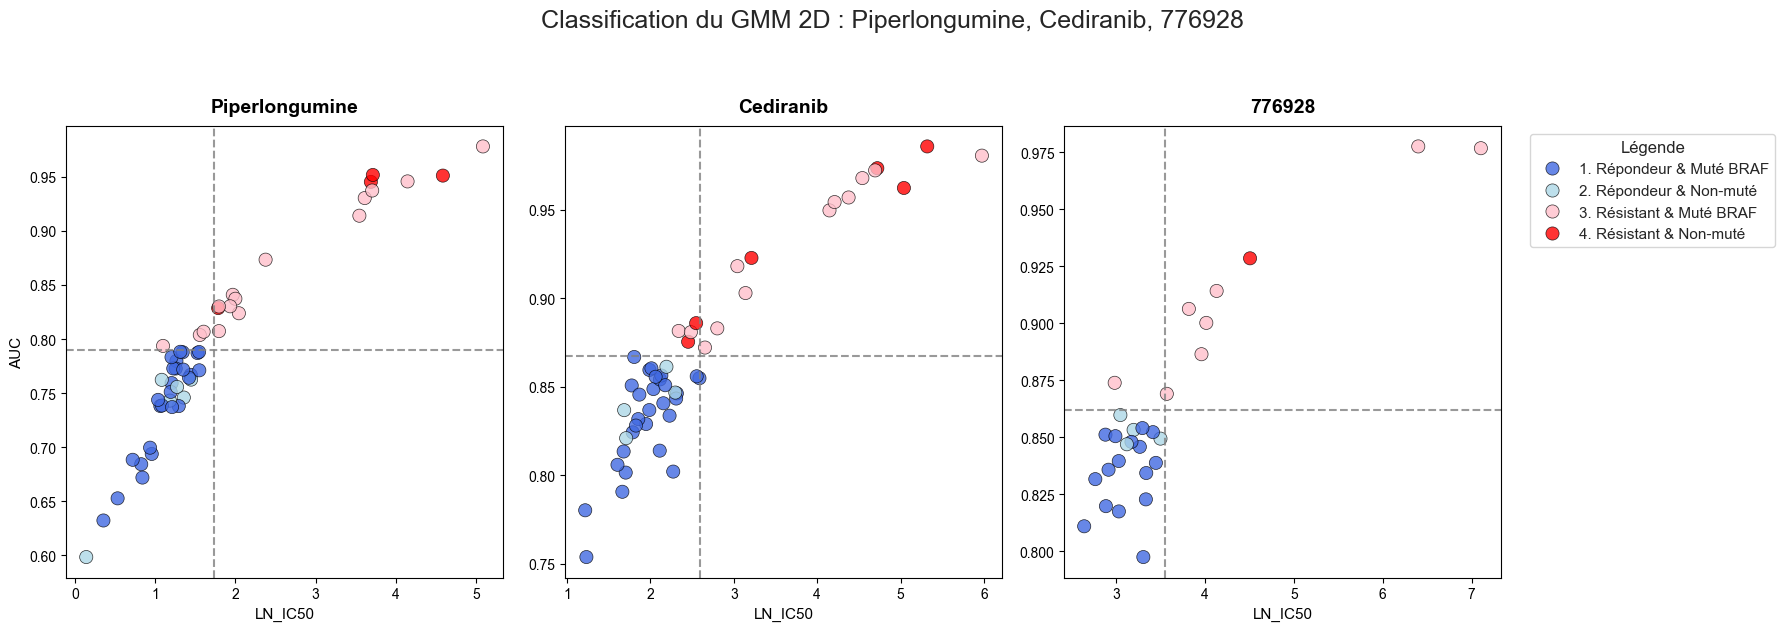

In [35]:
# 1.  3 médicaments 
medicaments_cibles = ["Piperlongumine", "Cediranib", "776928"] 

# 2. Ta fonction de catégorisation biologique
def categoriser_cellule(row):
    if row['is_responder'] == 1 and row['BRAF_Mut'] == 1:
        return '1. Répondeur & Muté BRAF'
    elif row['is_responder'] == 1 and row['BRAF_Mut'] == 0:
        return '2. Répondeur & Non-muté'
    elif row['is_responder'] == 0 and row['BRAF_Mut'] == 1:
        return '3. Résistant & Muté BRAF'
    else:
        return '4. Résistant & Non-muté'

# 3. Ta palette de couleurs sur-mesure
palette_couleurs = {
    '1. Répondeur & Muté BRAF': 'royalblue',      # Bleu vif (Cible idéale)
    '2. Répondeur & Non-muté': 'lightblue',       # Bleu clair (Sensible mais sans mutation)
    '3. Résistant & Muté BRAF': 'pink',           # Rose (Résistance intrinsèque)
    '4. Résistant & Non-muté': 'red'              # Rouge (Vrai négatif)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

for i, medicament in enumerate(medicaments_cibles):
    
    # Extraction et passage en Pandas
    df_plot = (
        df_categorized
        .filter(pl.col("DRUG_NAME") == medicament)
        .to_pandas()
    )
    
    if df_plot.empty:
        axes[i].set_title(f"Aucune donnée pour {medicament}")
        continue

    df_plot['Validation_Biologique'] = df_plot.apply(categoriser_cellule, axis=1)

    # Creation
    sns.scatterplot(
        data=df_plot, 
        x="LN_IC50",
        y="AUC",
        hue="Validation_Biologique", 
        palette=palette_couleurs,
        hue_order=[
            '1. Répondeur & Muté BRAF', 
            '2. Répondeur & Non-muté',
            '3. Résistant & Muté BRAF', 
            '4. Résistant & Non-muté'
        ],
        s=90,          
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,     
        ax=axes[i],
        legend=(i == 2)
    )

    # Ajout des "Frontières" GMM (Moyennes)
    mean_ic50 = df_plot["LN_IC50"].mean()
    mean_auc = df_plot["AUC"].mean()
    axes[i].axvline(x=mean_ic50, color='grey', linestyle='--', alpha=0.8)
    axes[i].axhline(y=mean_auc, color='grey', linestyle='--', alpha=0.8)
    axes[i].set_title(f"{medicament}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("LN_IC50", fontsize=11)
    
    if i == 0:
        axes[i].set_ylabel("AUC", fontsize=11)
    else:
        axes[i].set_ylabel("") 

plt.suptitle(f"Classification du GMM 2D : {', '.join(medicaments_cibles)}", fontsize=18, y=1.05)

if axes[2].get_legend() is not None:
    axes[2].legend(title="Légende", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [36]:
print(df_categorized["is_responder"].value_counts())
print(df_categorized["BRAF_Mut"].value_counts())

shape: (2, 2)
┌──────────────┬───────┐
│ is_responder ┆ count │
│ ---          ┆ ---   │
│ i32          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 15735 │
│ 1            ┆ 8023  │
└──────────────┴───────┘
shape: (2, 2)
┌──────────┬───────┐
│ BRAF_Mut ┆ count │
│ ---      ┆ ---   │
│ i32      ┆ u32   │
╞══════════╪═══════╡
│ 0        ┆ 4657  │
│ 1        ┆ 19101 │
└──────────┴───────┘


In [37]:
drug_name = "776928"
df_sb590885 = df_categorized.filter(pl.col("DRUG_NAME") == drug_name)

print(df_sb590885.select(["DRUG_NAME", "MAX_CONC", "LN_IC50", "is_responder"]).head())
print(f"MAX_CONC max pour {drug_name}:", df_sb590885.select(pl.col("MAX_CONC").max()).item())

shape: (5, 4)
┌───────────┬──────────┬──────────┬──────────────┐
│ DRUG_NAME ┆ MAX_CONC ┆ LN_IC50  ┆ is_responder │
│ ---       ┆ ---      ┆ ---      ┆ ---          │
│ str       ┆ f64      ┆ f64      ┆ i32          │
╞═══════════╪══════════╪══════════╪══════════════╡
│ 776928    ┆ 30.0     ┆ 4.506729 ┆ 0            │
│ 776928    ┆ 30.0     ┆ 3.818311 ┆ 0            │
│ 776928    ┆ 30.0     ┆ 3.266389 ┆ 1            │
│ 776928    ┆ 30.0     ┆ 6.399883 ┆ 0            │
│ 776928    ┆ 30.0     ┆ 3.49847  ┆ 1            │
└───────────┴──────────┴──────────┴──────────────┘
MAX_CONC max pour 776928: 30.0


Génération du graphique de validation 2D pour le 776928...


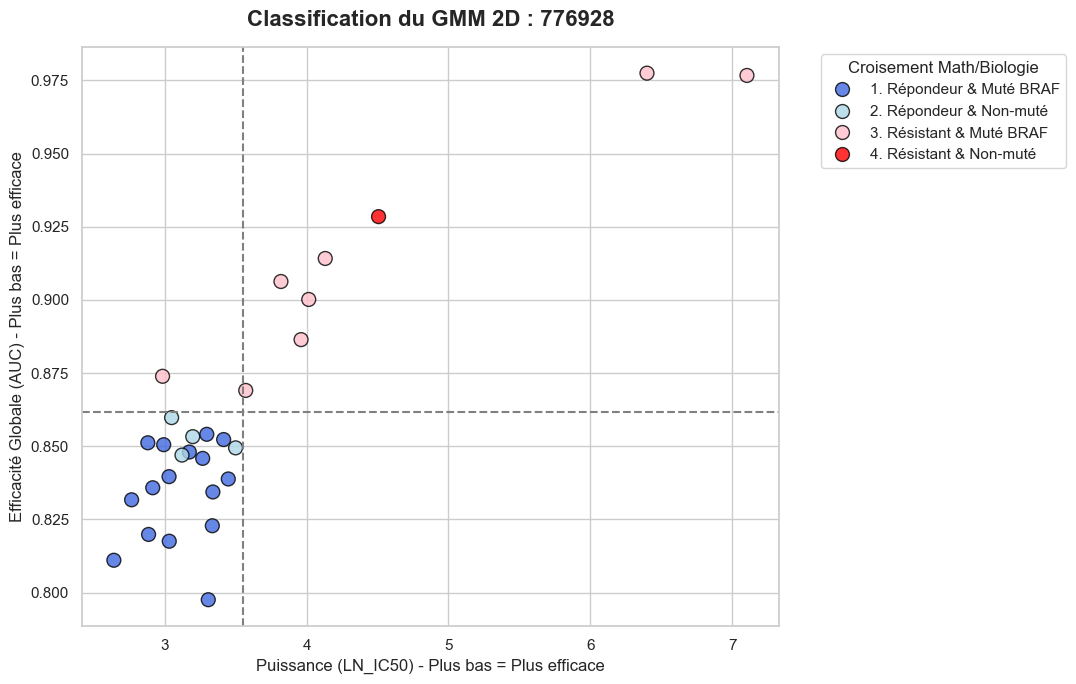

In [38]:
medicament_cible = "776928"

print(f"Génération du graphique de validation 2D pour le {medicament_cible}...")

df_plot = (
    df_categorized
    .filter(pl.col("DRUG_NAME") == medicament_cible)
    .to_pandas()
)

# Security
if df_plot.empty:
    print(f"Pas assez de données validées pour {medicament_cible}.")
else:
    def categoriser_cellule(row):
        if row['is_responder'] == 1 and row['BRAF_Mut'] == 1:
            return '1. Répondeur & Muté BRAF'
        elif row['is_responder'] == 1 and row['BRAF_Mut'] == 0:
            return '2. Répondeur & Non-muté'
        elif row['is_responder'] == 0 and row['BRAF_Mut'] == 1:
            return '3. Résistant & Muté BRAF'
        else:
            return '4. Résistant & Non-muté'

    df_plot['Validation_Biologique'] = df_plot.apply(categoriser_cellule, axis=1)

    # Configuration color
    palette_couleurs = {
        '1. Répondeur & Muté BRAF': 'royalblue',      # Bleu vif
        '2. Répondeur & Non-muté': 'lightblue',       # Bleu clair
        '3. Résistant & Muté BRAF': 'pink',           # Rose
        '4. Résistant & Non-muté': 'red'              # Rouge
    }

    plt.figure(figsize=(11, 7))
    sns.set_theme(style="whitegrid")

    # Nuage de points 
    scatter = sns.scatterplot(
        data=df_plot,
        x="LN_IC50",
        y="AUC",
        hue="Validation_Biologique",
        palette=palette_couleurs,
        hue_order=[
            '1. Répondeur & Muté BRAF', 
            '2. Répondeur & Non-muté',
            '3. Résistant & Muté BRAF', 
            '4. Résistant & Non-muté'
        ],
        s=100,
        edgecolor="black",
        linewidth=1,
        alpha=0.8
    )

    mean_ic50 = df_plot["LN_IC50"].mean()
    mean_auc = df_plot["AUC"].mean()

    plt.axvline(x=mean_ic50, color='grey', linestyle='--', linewidth=1.5)
    plt.axhline(y=mean_auc, color='grey', linestyle='--', linewidth=1.5)
    plt.title(f"Classification du GMM 2D : {medicament_cible}", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Puissance (LN_IC50) - Plus bas = Plus efficace", fontsize=12)
    plt.ylabel("Efficacité Globale (AUC) - Plus bas = Plus efficace", fontsize=12)

    plt.legend(
        title="Croisement Math/Biologie", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left',
        frameon=True
    )

    # Affichage
    plt.tight_layout()
    plt.show()

In [40]:
print("Extraction des cœurs de clusters GMM...")

# On calcule le centre (la moyenne) de CHAQUE cluster pour CHAQUE médicament
# Groupement par DRUG_NAME ET par is_responder
df_centres = df_categorized.group_by(["DRUG_NAME", "is_responder"]).agg(
    pl.col("LN_IC50").mean().alias("centre_ic50"),
    pl.col("AUC").mean().alias("centre_auc")
)

df_merged = df_categorized.join(df_centres, on=["DRUG_NAME", "is_responder"])

df_3groups = df_merged.with_columns(
    pl.when(
        # RÈGLE POUR LES SENSIBLES SÛRS (1) : 
        # Être classé 1 par le GMM + Être encore plus puissant/efficace que la moyenne de son propre groupe
        (pl.col("is_responder") == 1) & 
        (pl.col("LN_IC50") <= pl.col("centre_ic50")) & 
        (pl.col("AUC") <= pl.col("centre_auc"))
    )
    .then(1) # cluster Sensible
    
    .when(
        # RÈGLE POUR LES RÉSISTANTS SÛRS (0) : 
        # Être classé 0 par le GMM + Être encore plus résistant que la moyenne de son propre groupe
        (pl.col("is_responder") == 0) & 
        (pl.col("LN_IC50") >= pl.col("centre_ic50")) & 
        (pl.col("AUC") >= pl.col("centre_auc"))
    )
    .then(0)
    
    .otherwise(-1)
    .alias("is_responder_strict")
)

print("\nRépartition des 3 groupes (1 = Sensible sûr, 0 = Résistant sûr, -1 = So-so) :")
print(df_3groups["is_responder_strict"].value_counts())

Extraction des cœurs de clusters GMM...

Répartition des 3 groupes (1 = Sensible sûr, 0 = Résistant sûr, -1 = So-so) :
shape: (3, 2)
┌─────────────────────┬───────┐
│ is_responder_strict ┆ count │
│ ---                 ┆ ---   │
│ i32                 ┆ u32   │
╞═════════════════════╪═══════╡
│ 1                   ┆ 2968  │
│ 0                   ┆ 5829  │
│ -1                  ┆ 14961 │
└─────────────────────┴───────┘


/var/folders/ym/6j7rc0bd16gbp8l_nf8fjv0r0000gn/T/ipykernel_20855/1930759792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="is_responder_strict", data=df_3groups.to_pandas(), palette=["lightgrey", "red", "royalblue"])


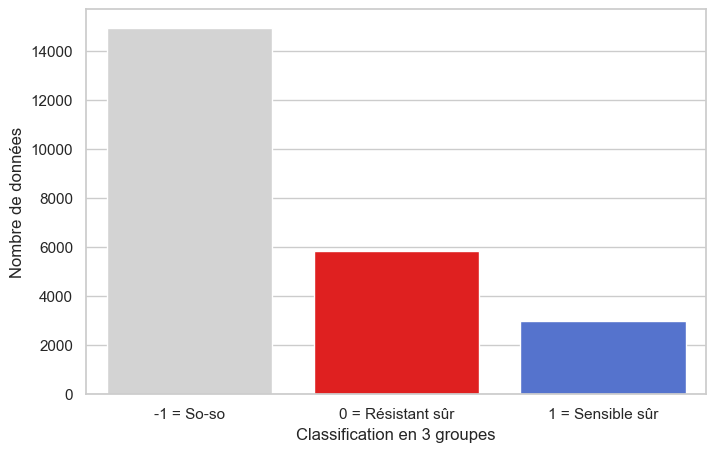

In [41]:
plt.figure(figsize=(8, 5))
sns.countplot(x="is_responder_strict", data=df_3groups.to_pandas(), palette=["lightgrey", "red", "royalblue"])
plt.xlabel("Classification en 3 groupes", fontsize=12)
plt.ylabel("Nombre de données", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=["-1 = So-so", "0 = Résistant sûr", "1 = Sensible sûr"])
plt.show()

In [42]:
# Répartition en pourcentages
repartition = df_3groups["is_responder_strict"].value_counts().with_columns(
    (pl.col("count") / df_3groups.height * 100).round(1).alias("pourcentage (%)")
)
print("Répartition globale des 3 groupes :")
print(repartition)

Répartition globale des 3 groupes :
shape: (3, 3)
┌─────────────────────┬───────┬─────────────────┐
│ is_responder_strict ┆ count ┆ pourcentage (%) │
│ ---                 ┆ ---   ┆ ---             │
│ i32                 ┆ u32   ┆ f64             │
╞═════════════════════╪═══════╪═════════════════╡
│ -1                  ┆ 14961 ┆ 63.0            │
│ 0                   ┆ 5829  ┆ 24.5            │
│ 1                   ┆ 2968  ┆ 12.5            │
└─────────────────────┴───────┴─────────────────┘


In [43]:
# L'écart moyen d'IC50 et d'AUC entre tes groupes sûrs
contraste = df_3groups.filter(pl.col("is_responder_strict").is_in([0, 1])).group_by("is_responder_strict").agg(
    pl.col("LN_IC50").mean().round(2).alias("Moyenne_Puissance(ln(IC50))"),
    pl.col("AUC").mean().round(2).alias("Moyenne_Efficacité(AUC)")
)
print("\nContraste entre les groupes sûrs :")
print(contraste)


Contraste entre les groupes sûrs :
shape: (2, 3)
┌─────────────────────┬─────────────────────────────┬─────────────────────────┐
│ is_responder_strict ┆ Moyenne_Puissance(ln(IC50)) ┆ Moyenne_Efficacité(AUC) │
│ ---                 ┆ ---                         ┆ ---                     │
│ i32                 ┆ f64                         ┆ f64                     │
╞═════════════════════╪═════════════════════════════╪═════════════════════════╡
│ 0                   ┆ 4.07                        ┆ 0.94                    │
│ 1                   ┆ 0.26                        ┆ 0.66                    │
└─────────────────────┴─────────────────────────────┴─────────────────────────┘


In [44]:
# Les drogues qui ont le plus de cellules dans le groupe 1
top_drogues = df_3groups.filter(pl.col("is_responder_strict") == 1).group_by("DRUG_NAME").agg(
    pl.col("ModelID").n_unique().alias("Nombre_de_Cellules_Sensibles")
).sort("Nombre_de_Cellules_Sensibles", descending=True)

print("\nTop 5 best drgus:")
print(top_drogues.head(5))


Top 5 best drgus:
shape: (5, 2)
┌──────────────┬──────────────────────────────┐
│ DRUG_NAME    ┆ Nombre_de_Cellules_Sensibles │
│ ---          ┆ ---                          │
│ str          ┆ u32                          │
╞══════════════╪══════════════════════════════╡
│ WYE-125132   ┆ 16                           │
│ Trametinib   ┆ 16                           │
│ Thapsigargin ┆ 16                           │
│ SCH772984    ┆ 15                           │
│ Dinaciclib   ┆ 14                           │
└──────────────┴──────────────────────────────┘


In [ ]:
#df_3groups.write_csv("data/Dataset_sanger_3g.csv")